# Model Evaluation

This notebook evaluates the final hybrid CNN–Vision Transformer on the Fashion-MNIST test set.

It loads the trained model and evaluates its performance using overall accuracy, macro-averaged precision, recall, and F1-score, as well as per-class metrics and a confusion matrix.

### Results

* **Test samples:** 10,000
* **Test accuracy:** 90.22%
* **Macro F1-score:** 0.9015
* **Macro precision:** 0.9018
* **Macro recall:** 0.9022

The evaluation results provide a detailed analysis of the final model's classification performance across all ten Fashion-MNIST classes.


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from transformers import ViTForImageClassification, ViTConfig
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report, 
                            accuracy_score, f1_score, precision_score, 
                            recall_score, precision_recall_fscore_support)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

2025-11-05 16:54:07.962982: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Using device: cpu


In [2]:
test_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

testset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=test_transform)
test_loader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

print(f"Test samples: {len(testset)}")

Test samples: 10000


In [3]:
# Recreate model architecture (same as before)
class CNNFeatureExtractor(nn.Module):
    def __init__(self, in_channels=1, out_channels=64):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
    
    def forward(self, x):
        return self.conv_layers(x)

class HybridViT(nn.Module):
    def __init__(self, vit_config, num_classes=10):
        super().__init__()
        self.cnn_extractor = CNNFeatureExtractor(in_channels=1, out_channels=64)
        vit_config.num_channels = 64
        vit_config.image_size = 16
        self.vit = ViTForImageClassification(vit_config)
    
    def forward(self, x):
        x = self.cnn_extractor(x)
        outputs = self.vit(x)
        return outputs.logits

# Load model
config = ViTConfig(
    image_size=16, patch_size=4, num_channels=64, num_labels=10,
    hidden_size=256, num_hidden_layers=6, num_attention_heads=8, intermediate_size=512
)

model = HybridViT(config, num_classes=10)
model.load_state_dict(torch.load('modified_vit_model.pth'))
model = model.to(device)
model.eval()

print("Modified model loaded successfully")

Modified model loaded successfully


In [4]:
# Get predictions for entire test set
all_preds = []
all_labels = []
all_probs = []

print("Getting predictions...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print(f"Got predictions for {len(all_labels)} samples")

Getting predictions...
Got predictions for 10000 samples


In [5]:
# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
macro_precision = precision_score(all_labels, all_preds, average='macro')
macro_recall = recall_score(all_labels, all_preds, average='macro')

print("\n" + "="*60)
print("OVERALL METRICS - MODIFIED MODEL")
print("="*60)
print(f"Accuracy:          {accuracy*100:.2f}%")
print(f"Macro F1-Score:    {macro_f1:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}")
print(f"Macro Precision:   {macro_precision:.4f}")
print(f"Macro Recall:      {macro_recall:.4f}")
print("="*60)


OVERALL METRICS - MODIFIED MODEL
Accuracy:          90.22%
Macro F1-Score:    0.9015
Weighted F1-Score: 0.9015
Macro Precision:   0.9018
Macro Recall:      0.9022


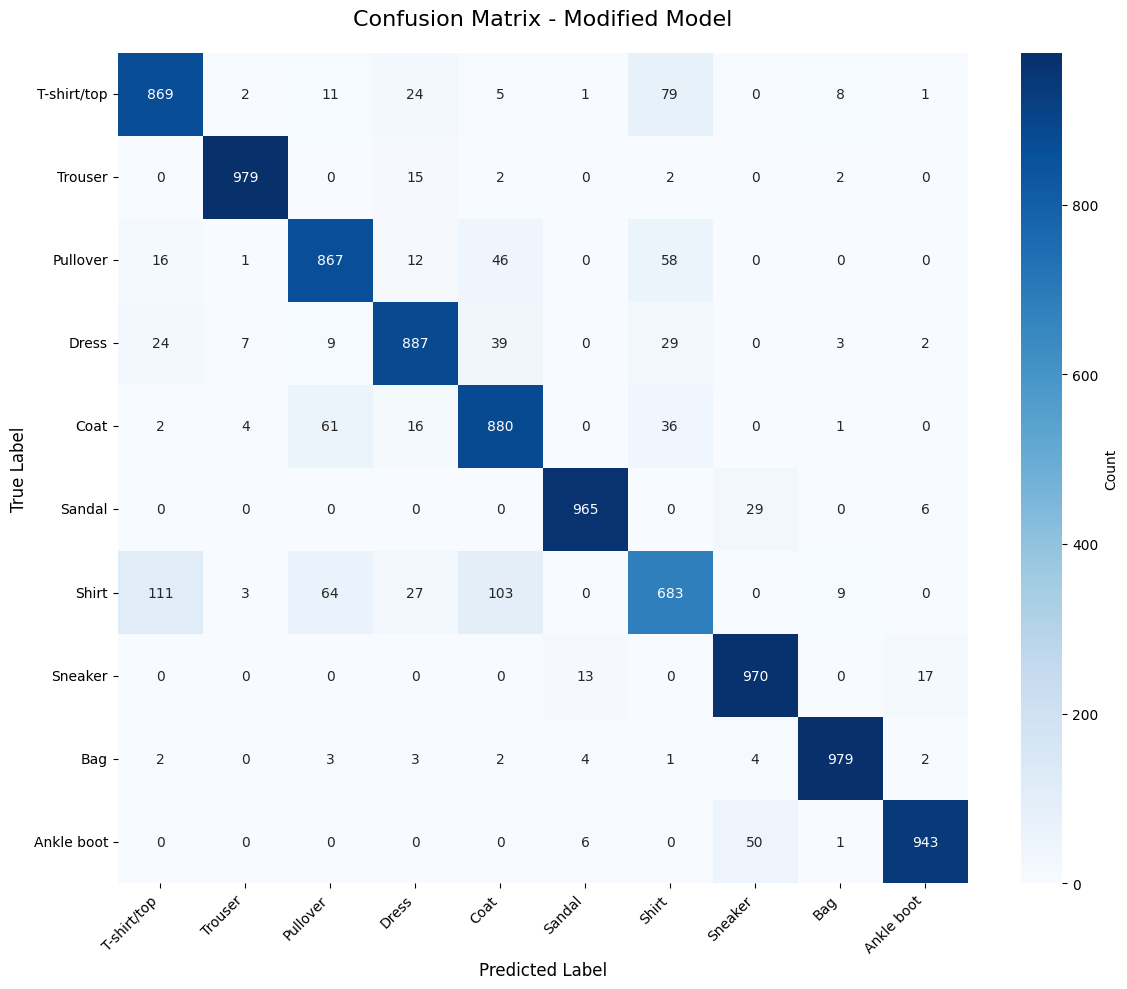

Confusion matrix saved


In [6]:
# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=class_names,
           yticklabels=class_names,
           cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Modified Model', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_modified.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved")


PER-CLASS CLASSIFICATION REPORT
              precision    recall  f1-score   support

 T-shirt/top     0.8486    0.8690    0.8587      1000
     Trouser     0.9829    0.9790    0.9810      1000
    Pullover     0.8542    0.8670    0.8605      1000
       Dress     0.9014    0.8870    0.8942      1000
        Coat     0.8171    0.8800    0.8474      1000
      Sandal     0.9757    0.9650    0.9703      1000
       Shirt     0.7691    0.6830    0.7235      1000
     Sneaker     0.9212    0.9700    0.9450      1000
         Bag     0.9761    0.9790    0.9775      1000
  Ankle boot     0.9712    0.9430    0.9569      1000

    accuracy                         0.9022     10000
   macro avg     0.9018    0.9022    0.9015     10000
weighted avg     0.9018    0.9022    0.9015     10000



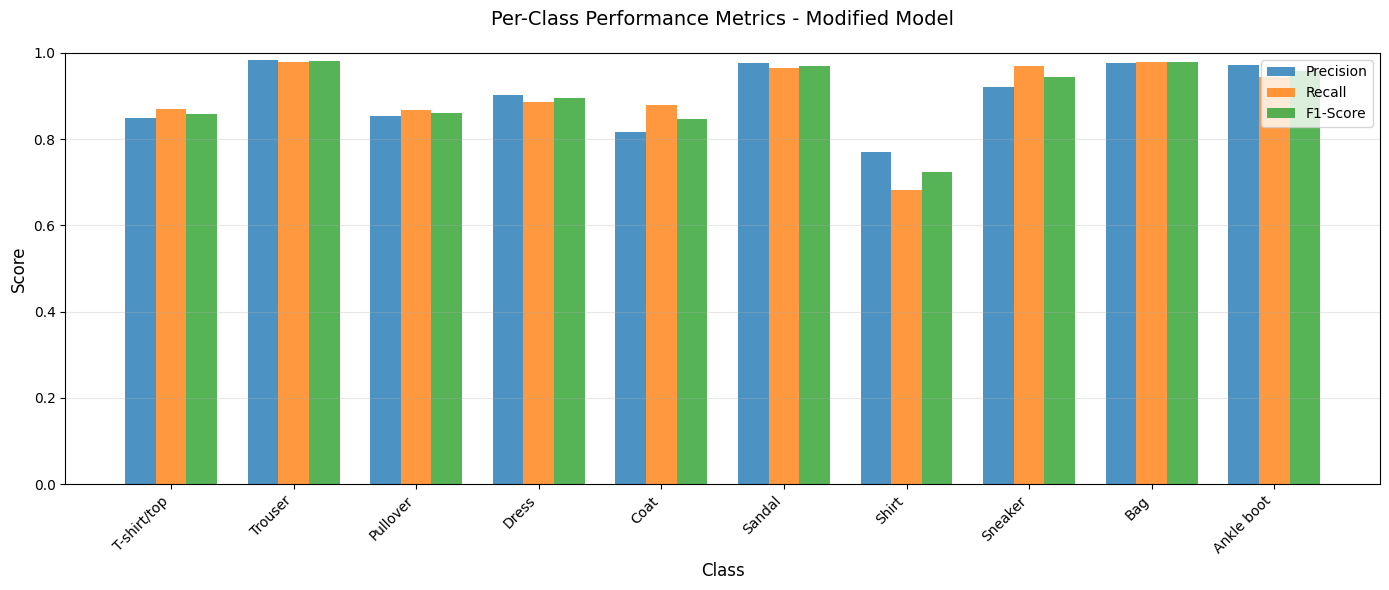

Per-class metrics plotted


In [7]:
# Detailed classification report
print("\n" + "="*60)
print("PER-CLASS CLASSIFICATION REPORT")
print("="*60)
print(classification_report(all_labels, all_preds, 
                          target_names=class_names,
                          digits=4))

# Get per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, average=None
)

# Plot per-class metrics
x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, precision, width, label='Precision', alpha=0.8)
ax.bar(x, recall, width, label='Recall', alpha=0.8)
ax.bar(x + width, f1, width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Performance Metrics - Modified Model', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.0])

plt.tight_layout()
plt.savefig('per_class_metrics_modified.png', dpi=300, bbox_inches='tight')
plt.show()

print("Per-class metrics plotted")

In [8]:
# Create comprehensive comparison table
baseline_acc = 83.80
modified_acc = accuracy * 100

comparison_data = {
    'Model': ['Baseline ViT', 'Modified ViT', 'Improvement'],
    'Accuracy (%)': [baseline_acc, modified_acc, modified_acc - baseline_acc],
    'Training Time (min)': [325.86, 142.99, 142.99 - 325.86]
}

print("\n" + "="*60)
print("BASELINE VS MODIFIED COMPARISON")
print("="*60)
for i in range(len(comparison_data['Model'])):
    print(f"{comparison_data['Model'][i]:20s} | "
          f"Acc: {comparison_data['Accuracy (%)'][i]:6.2f}% | "
          f"Time: {comparison_data['Training Time (min)'][i]:7.2f} min")
print("="*60)
print(f"\nModified model is {modified_acc - baseline_acc:.2f}% more accurate!")
print(f"Modified model trained {((325.86 - 142.99)/325.86)*100:.1f}% faster!")


BASELINE VS MODIFIED COMPARISON
Baseline ViT         | Acc:  83.80% | Time:  325.86 min
Modified ViT         | Acc:  90.22% | Time:  142.99 min
Improvement          | Acc:   6.42% | Time: -182.87 min

Modified model is 6.42% more accurate!
Modified model trained 56.1% faster!


In [9]:
# Save evaluation results
import pickle

eval_results = {
    'accuracy': accuracy,
    'macro_f1': macro_f1,
    'weighted_f1': weighted_f1,
    'macro_precision': macro_precision,
    'macro_recall': macro_recall,
    'confusion_matrix': cm,
    'per_class_precision': precision,
    'per_class_recall': recall,
    'per_class_f1': f1,
    'per_class_support': support,
    'predictions': all_preds,
    'labels': all_labels,
    'probabilities': all_probs
}

with open('evaluation_results.pkl', 'wb') as f:
    pickle.dump(eval_results, f)

print("All evaluation results saved to 'evaluation_results.pkl'")
print("\nEVALUATION COMPLETE!")

All evaluation results saved to 'evaluation_results.pkl'

EVALUATION COMPLETE
